## 0. Environment Setup

In [1]:
import warnings
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore")
plt.style.use("dark_background")

COLORS = {
    "primary": "#4FC3F7",
    "success": "#66BB6A",
    "danger": "#EF5350",
    "warning": "#FFA726",
    "accent": "#AB47BC",
    "neutral": "#B0BEC5",
}

# —— V3 Architecture Constants ————————————————————————————————————————————————
SUPER_STATE_DIM = 224
ACTION_DIM = 4
UNCERTAINTY_CRITICAL = 0.80
PROFIT_TARGET = 0.20
MAX_DRAWDOWN_LIMIT = 0.10
DAILY_LOSS_LIMIT = 0.03

# —— Curriculum phase lengths —————————————————————————————————————————————————
PHASE_A_EPOCHS = 20
PHASE_B_EPOCHS = 20
PHASE_C_EPOCHS = 30

# —— PPO hyperparameters ——————————————————————————————————————————————————————
GAMMA = 0.99
LAMBDA_GAE = 0.95
CLIP_EPS = 0.20
VALUE_COEF = 0.50
ENTROPY_COEF = 0.01
LR = 3e-4
BATCH_SIZE = 128
PPO_EPOCHS = 4
MC_DROPOUT_N = 10

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.distributions import Beta

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"PyTorch {torch.__version__} | Device: {DEVICE}")
except ImportError:
    print("PyTorch required: pip install torch")
    raise

PyTorch 2.10.0+cu128 | Device: cuda


## 1. Trading Environment

In [2]:
class LuminaTradingEnv:
    """
    Event-driven trading simulation environment (Gymnasium-compatible).
    Enforces the three-layer Safety Arbitrator at every step:
        Profit-Take @ +20%, Drawdown CV @ -10%, Daily Loss CB @ -3%.
    "The ML model proposes, but the Safety Arbitrator decides."
    Maps to: backend/simulation/environments/base_env.py
    """

    def __init__(
        self,
        prices: np.ndarray,
        super_states: np.ndarray,
        initial_capital: float = 100_000.0,
        vol_warp: float = 1.0,
    ):
        self.prices = prices
        self.states = super_states
        self.captial0 = initial_capital
        self.vol_warp = vol_warp
        self.n = len(prices) - 1
        self._reset_state()

    def _reset_state(self) -> None:
        self._t = 0
        self._capital = self.captial0
        self._position = 0.0  # signed fraction of capital in market
        self._entry_px = None
        self._day_cap = self.captial0
        self._equity: list[float] = []
        self._safe_evts: list[str] = []

    @property
    def obs_dim(self) -> int:
        """Super-State (224) + 5 portfolio features."""
        return SUPER_STATE_DIM + 5

    def _portfolio_features(self) -> np.ndarray:
        """Five normalised portfolio-state scalars appended to Super-State."""
        unrealised = 0.0
        if self._entry_px and self._position != 0:
            unrealised = self.prices[self._t] / self._entry_px - 1
        return np.array(
            [
                self._position,
                (self._capital / self.captial0) - 1,
                unrealised,
                min(1.0, self._t / max(self.n, 1)),
                1.0 if self._position != 0 else 0.0,
            ],
            dtype=np.float32,
        )

    def _obs(self) -> np.ndarray:
        ss = (
            self.states[self._t]
            if self._t < len(self.states)
            else self.states[-1]
        )
        return np.concatenate([ss, self._portfolio_features()])

    def reset(self) -> np.ndarray:
        self._reset_state()
        return self._obs()

    def _safety_check(self, action: np.ndarray, price: float) -> tuple:
        """Layer-2 & Layer-3 Safety Arbitrator rules."""
        safe = action.copy()
        evt = ""

        if self._position != 0 and self._entry_px:
            unreal = (price / self._entry_px - 1) * np.sign(self._position)
            if unreal >= PROFIT_TARGET:
                safe = np.array([0.0, 1.0, 0.0, 0.5])
                evt = f"PROFIT_TARGET + {unreal:.2%}"
            elif unreal <= -MAX_DRAWDOWN_LIMIT:
                safe = np.array([0.0, 1.0, 0.0, 0.5])
                evt = f"MAX_DRAWDOWN {unreal:.2%}"

        daily_pnl = (self._capital / self._day_cap) - 1
        if daily_pnl <= -DAILY_LOSS_LIMIT:
            safe = np.array([0.0, 1.0, 0.0, 0.5])
            evt = f"DAILY_LOSS {daily_pnl:.2%}"

        return safe, evt

    def step(self, action: np.ndarray) -> tuple:
        """One environment step with safety enforcement."""
        px = float(self.prices[self._t])
        nxt_px = float(self.prices[self._t + 1])

        # Phase B: volaility warp
        if self.vol_warp != 1.0:
            ret = (nxt_px / px - 1) * self.vol_warp
            nxt_px = px * (1 + ret)

        safe, evt = self._safety_check(action, px)
        if evt:
            self._safe_evts.append(f"t={self._t}: {evt}")

        direction = float(np.clip(safe[0], -1.0, 1.0))
        sizing = float(np.clip(safe[2], 0.0, 1.0))

        # Mark-to-market PnL
        pnl = (nxt_px / px - 1) * self._position * self._capital
        self._capital += pnl

        # Update position
        prev = self._position
        self._position = direction * sizing
        if self._position != 0 and prev == 0:
            self._entry_px = px
        elif self._position == 0:
            self._entry_px = None

        self._equity.append(self._capital)
        self._t += 1
        done = self._t >= self.n - 1

        # Risk-adjusted reward (Sharpe-style)
        step_ret = pnl / self.captial0
        vol = abs(nxt_px / px - 1) + 1e-8
        eq = np.array(self._equity)
        peak = eq.max() if len(eq) else self.captial0
        dd_pen = max(0, 1 - self._capital / peak) * 2.0
        reward = float(step_ret / vol - dd_pen - abs(self._position) * 1e-4)

        return self._obs(), reward, done, {"capital": self._capital}

    def stats(self) -> dict:
        if not self._equity:
            return {}
        eq = np.array(self._equity)
        ret = np.diff(eq) / eq[:-1]
        dd = (
            (eq - np.maximum.accumulate(eq)) / np.maximum.accumulate(eq)
        ).min()
        return {
            "total_return": (eq[-1] / self.captial0 - 1),
            "sharpe": ret.mean() / (ret.std() + 1e-8) * np.sqrt(252),
            "max_dd": float(dd),
            "n_safe": len(self._safe_evts),
            "equity": eq,
        }

## 2. Actor-Critic Network (PPO + Uncertainty Head)

In [3]:
class LuminaActorCritic(nn.Module):
    """
    PPO Actor-Critic with three heads (§5):
      1. Policy Head      — Beta distribution for continuous actions
      2. Critic (Value)   — V(s) expected cumulative reward
      3. Uncertainty Head — fast epistemic entropy estimate

    Action vector (§5):
      [0] direction  : Beta → scaled to [-1, +1]  long/short
      [1] urgency    : Beta → [0, 1]               limit/market
      [2] sizing     : Beta → [0, 1]               risk capital %
      [3] stop_dist  : Beta → [0, 1]               ATR stop multiplier

    Implements: backend/cognition/agent/ppo_continuous.py
                backend/cognition/policy/networks.py
                backend/cognition/policy/distributions.py
    """

    def __init__(
        self,
        obs_dim: int = SUPER_STATE_DIM + 5,
        action_dim: int = ACTION_DIM,
        hidden: int = 256,
        dropout: float = 0.15,
    ):
        super().__init__()

        # Shared backbone — processes 224d Super-State + portfolio features
        self.backbone = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.LayerNorm(hidden),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
            nn.ELU(),
            nn.Dropout(dropout),
        )

        # Head 1: Policy — Beta distribution parameters α, β > 0 per action
        self.policy_head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ELU(),
            nn.Linear(hidden // 2, action_dim * 2),
            nn.Softplus(),  # Guarantees α, β > 0
        )

        # Head 2: Critic — state value V(s)
        self.value_head = nn.Sequential(
            nn.Linear(hidden, hidden // 2),
            nn.ELU(),
            nn.Linear(hidden // 2, 1),
        )

        # Head 3: Uncertainty — fast approximation of MC Dropout variance
        self.uncertainty_head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.ELU(),
            nn.Linear(64, 1),
            nn.Sigmoid(),  # [0, 1] normalised
        )

    def forward(self, obs: torch.Tensor) -> dict:
        feat = self.backbone(obs)
        params = self.policy_head(feat) + 1e-6
        alpha, beta = params.chunk(2, dim=-1)

        dist = Beta(alpha, beta)
        actions = dist.rsample()
        log_probs = dist.log_prob(actions.clamp(1e-6, 1 - 1e-6)).sum(-1)
        values = self.value_head(feat).squeeze(-1)
        unc = self.uncertainty_head(feat.detach()).squeeze(-1)

        return {
            "actions": actions,
            "log_probs": log_probs,
            "values": values,
            "uncertainty": unc,
            "dist": dist,
        }

    @staticmethod
    def scale_actions(raw: torch.Tensor) -> torch.Tensor:
        """Map Beta [0,1]^4 → action ranges; direction [0,1]→[-1,+1]."""
        scaled = raw.clone()
        scaled[:, 0] = raw[:, 0] * 2 - 1
        return scaled


# Quick sanity check
model_ac = LuminaActorCritic().to(DEVICE)
obs_dummy = torch.randn(8, SUPER_STATE_DIM + 5).to(DEVICE)
with torch.no_grad():
    out = model_ac(obs_dummy)
n_params = sum(p.numel() for p in model_ac.parameters() if p.requires_grad)
print(f"LuminaActorCritic ✅  params={n_params:,}")
print(f"  actions: {out['actions'].shape}  values: {out['values'].shape}")

LuminaActorCritic ✅  params=209,162
  actions: torch.Size([8, 4])  values: torch.Size([8])


## 3. MC Dropout Uncertainty Estimator (Risk Gate — Layer 1)

In [4]:
def estimate_uncertainty(
    model: LuminaActorCritic, obs: torch.Tensor, n_passes: int = MC_DROPOUT_N
) -> float:
    """
    Run N forward passes with Dropout active, measure action variance.
    "If the 10 runs produce widely different outputs → High Entropy
    (Confused)." (§5)
    Implements: backend/cognition/agent/uncertainty.py → UncertaintyEstimator
    """
    model.train()  # Dropout stays ON
    all_actions = []
    with torch.no_grad():
        for _ in range(n_passes):
            all_actions.append(model(obs)["actions"].unsqueeze(0))
    model.eval()
    stacked = torch.cat(all_actions, dim=0)  # (N, batch, action_dim)
    variance = stacked.var(dim=0).mean(dim=-1)  # (batch,) mean variance
    unc = (variance / (variance + 0.05)).mean().item()  # normalise to [0,1]
    return unc


unc = estimate_uncertainty(model_ac, obs_dummy, n_passes=3)
risk_gate = {
    "YES — defensive action"
    if unc > UNCERTAINTY_CRITICAL
    else "NO — RL proceeds"
}
print(
    f"MC Dropout uncertainty (test): {unc:.4f} | "
    f"Threshold: {UNCERTAINTY_CRITICAL}"
)
print(f"  Risk Gate veto: {risk_gate}")

MC Dropout uncertainty (test): 0.6212 | Threshold: 0.8
  Risk Gate veto: {'NO — RL proceeds'}


## 4. GAE and PPO Update

In [5]:
def compute_gae(rewards, values, gamma=GAMMA, lam=LAMBDA_GAE):
    """
    Generalised Advantage Estimation (GAE-λ) — baseline variance reduction.
    """
    advantages = []
    gae = 0.0
    for t in reversed(range(len(rewards))):
        next_v = values[t + 1] if t + 1 < len(values) else 0.0
        delta = rewards[t] + gamma * next_v - values[t]
        gae = delta + gamma * lam * gae
        advantages.insert(0, gae)
    returns = [a + v for a, v in zip(advantages, values)]
    return (
        np.array(returns, dtype=np.float32),
        np.array(advantages, dtype=np.float32),
    )


def ppo_update(model, optimizer, obs_t, act_t, old_lp_t, ret_t, adv_t):
    """
    Clipped PPO objective update. Implements ppo_continuous.py → update().
    """
    adv_t = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)
    metrics = {"policy": 0.0, "value": 0.0, "entropy": 0.0}

    for _ in range(PPO_EPOCHS):
        idx = torch.randperm(len(obs_t))[: min(BATCH_SIZE, len(obs_t))]
        out = model(obs_t[idx])
        dist = out["dist"]
        lp_new = dist.log_prob(act_t[idx].clamp(1e-6, 1 - 1e-6)).sum(-1)

        ratio = (lp_new - old_lp_t[idx]).exp()
        clipped = ratio.clamp(1 - CLIP_EPS, 1 + CLIP_EPS)
        pl = -torch.min(ratio * adv_t[idx], clipped * adv_t[idx]).mean()
        vl = F.mse_loss(out["values"], ret_t[idx])
        ent = dist.entropy().sum(-1).mean()
        loss = pl + VALUE_COEF * vl - ENTROPY_COEF * ent

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()

        metrics["policy"] += pl.item()
        metrics["value"] += vl.item()
        metrics["entropy"] += ent.item()

    return {k: v / PPO_EPOCHS for k, v in metrics.items()}

## 5. Data Setup

In [6]:
END = datetime.today()
START = END - timedelta(days=365 * 2)
raw = yf.download(
    "SPY",
    start=START,
    end=END,
    interval="1d",
    progress=False,
    auto_adjust=True,
)
prices = raw["Close"].squeeze().dropna().values.astype(np.float32)
N = len(prices)

# Placeholder Super-States (in production: loaded from Redis Feature Store)
# Semantic embeddings simulate regime-aware signal (bull/bear/crash/sideways)
np.random.seed(42)
ss_base = np.random.randn(N, SUPER_STATE_DIM).astype(np.float32) * 0.5
# Inject some structure: late-2022 bear market ~ negative semantic activations
ss_base[int(N * 0.3) : int(N * 0.6), :64] -= 0.8
# Don't append zeros here — the environment already adds 5 portfolio features
super_states_all = ss_base

print(f"Price bars : {N}")
print(f"Super-State shape : {super_states_all.shape}")

Price bars : 501
Super-State shape : (501, 224)


## 6. Phase A — Behavioural Cloning (The Apprentice)

In [7]:

# "Force the Agent to mimic the Teacher's decisions.
#  This solves the Cold Start problem." (§7-A)
print("=" * 52)
print("  PHASE A — BEHAVIOURAL CLONING (The Apprentice)")
print("=" * 52)

expert_path = Path("03_expert_labels.parquet")
if expert_path.exists():
    df_exp = pd.read_parquet(expert_path)
    exp_act = df_exp[
        ["v3_direction", "v3_urgency", "v3_sizing", "v3_stop_dist"]
    ].values.astype(np.float32)
    exp_act[:, 0] = (
        exp_act[:, 0] + 1
    ) / 2  # direction [-1,1] → [0,1] for Beta
    n_exp = min(len(exp_act), N)
    print(f"  Loaded {n_exp} expert labels from notebook 03")
else:
    n_exp = min(N, 800)
    # Synthetic expert: mainly long with moderate conviction
    exp_act = np.clip(
        np.random.beta(3, 2, (n_exp, ACTION_DIM)), 0.01, 0.99
    ).astype(np.float32)
    print(f"  Synthetic expert labels ({n_exp} samples)")

model_A = LuminaActorCritic().to(DEVICE)
optim_A = torch.optim.Adam(model_A.parameters(), lr=1e-3)
bc_losses = []

# Pad super-states with 5 zero portfolio features to match model input dim (229)
portfolio_pad = np.zeros((n_exp, 5), dtype=np.float32)
states_A_np = np.concatenate([super_states_all[:n_exp], portfolio_pad], axis=1)
states_A = torch.tensor(states_A_np, dtype=torch.float32).to(DEVICE)
exp_act_t = torch.tensor(exp_act[:n_exp]).to(DEVICE)

for ep in range(PHASE_A_EPOCHS):
    model_A.train()
    idx = torch.randperm(n_exp)[:BATCH_SIZE]
    out = model_A(states_A[idx])
    bc_loss = (
        -out["dist"]
        .log_prob(exp_act_t[idx].clamp(1e-6, 1 - 1e-6))
        .sum(-1)
        .mean()
    )

    optim_A.zero_grad()
    bc_loss.backward()
    optim_A.step()
    bc_losses.append(bc_loss.item())
    if (ep + 1) % 5 == 0:
        print(
            f"  Ep [{ep + 1:>2}/{PHASE_A_EPOCHS}]  "
            f"BC Loss: {bc_loss.item():.4f}"
        )

print(f"  Phase A done — final BC loss: {bc_losses[-1]:.4f}")


  PHASE A — BEHAVIOURAL CLONING (The Apprentice)
  Synthetic expert labels (501 samples)
  Ep [ 5/20]  BC Loss: -0.3021
  Ep [10/20]  BC Loss: -1.1342
  Ep [15/20]  BC Loss: -1.0449
  Ep [20/20]  BC Loss: -1.3322
  Phase A done — final BC loss: -1.3322


## 7. Phase B — Domain Randomisation (The Matrix)

In [8]:
# "Warp 1 (Volatility): Multiply historical volatility by 2x, 3x, or 5x.
#  Warp 2 (Noise): Introduce spread widening and slippage spikes.
#  Warp 3 (Blackout): Simulate data feed outages." (§7-B)
print("\n" + "=" * 52)
print("  PHASE B — DOMAIN RANDOMISATION (The Matrix)")
print("=" * 52)

model_B = LuminaActorCritic().to(DEVICE)
model_B.load_state_dict(model_A.state_dict())
optim_B = torch.optim.Adam(model_B.parameters(), lr=LR)
VOL_WARPS = [1.0, 2.0, 3.0, 5.0]
phase_b_results = []

for warp in VOL_WARPS:
    ep_returns = []
    for ep in range(PHASE_B_EPOCHS // len(VOL_WARPS)):
        env = LuminaTradingEnv(prices, super_states_all, vol_warp=warp)
        obs = env.reset()
        done = False
        obs_b, act_b, lp_b, val_b, rew_b = [], [], [], [], []

        while not done:
            obs_t = (
                torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            )
            unc = estimate_uncertainty(model_B, obs_t, n_passes=3)

            if unc > UNCERTAINTY_CRITICAL:
                raw_a = np.array([[0.5, 0.3, 0.0, 0.5]], dtype=np.float32)
                lp_v = -4.0
                val_v = 0.0
            else:
                model_B.eval()
                with torch.no_grad():
                    out = model_B(obs_t)
                raw_a = out["actions"].cpu().numpy()
                lp_v = out["log_probs"][0].item()
                val_v = out["values"][0].item()

            scaled_a = np.clip(raw_a[0], 0.01, 0.99)
            exec_a = scaled_a.copy()
            exec_a[0] = scaled_a[0] * 2 - 1

            obs, reward, done, _ = env.step(exec_a)
            obs_b.append(obs)
            act_b.append(scaled_a)
            lp_b.append(lp_v)
            val_b.append(val_v)
            rew_b.append(reward)

        stats = env.stats()
        ep_returns.append(stats.get("total_return", 0))

        if len(obs_b) >= BATCH_SIZE:
            ret_arr, adv_arr = compute_gae(rew_b, val_b)
            ppo_update(
                model_B,
                optim_B,
                torch.tensor(np.array(obs_b), dtype=torch.float32).to(DEVICE),
                torch.tensor(np.array(act_b), dtype=torch.float32).to(DEVICE),
                torch.tensor(np.array(lp_b), dtype=torch.float32).to(DEVICE),
                torch.tensor(ret_arr).to(DEVICE),
                torch.tensor(adv_arr).to(DEVICE),
            )

    avg_r = float(np.mean(ep_returns)) if ep_returns else 0.0
    phase_b_results.append({"warp": warp, "avg_return": avg_r})
    print(f"  Warp {warp:.0f}x → Avg return: {avg_r:+.4f}")


  PHASE B — DOMAIN RANDOMISATION (The Matrix)
  Warp 1x → Avg return: -0.0003
  Warp 2x → Avg return: +0.0275
  Warp 3x → Avg return: +0.0719
  Warp 5x → Avg return: +0.0528


## 8. Phase C — Pure PPO RL (The Master)

In [9]:
# "Unleash the objective function: Maximise Sharpe / Minimise Max Drawdown.
#  If the agent finds a strategy that violates a moving average but yields
#  a higher Sharpe Ratio, it adopts it. This is where Alpha is
#  discovered." (§7-C)
print("\n" + "=" * 55)
print("  PHASE C — PURE RL (The Master — Sharpe Maximisation)")
print("=" * 55)

model_C = LuminaActorCritic().to(DEVICE)
model_C.load_state_dict(model_B.state_dict())
optim_C = torch.optim.Adam(model_C.parameters(), lr=LR * 0.5)
sched_C = torch.optim.lr_scheduler.CosineAnnealingLR(
    optim_C, T_max=PHASE_C_EPOCHS
)

phase_c = {
    "returns": [],
    "sharpe": [],
    "max_dd": [],
    "safety": [],
    "ppo_loss": [],
}

for ep in range(PHASE_C_EPOCHS):
    env = LuminaTradingEnv(prices, super_states_all, vol_warp=1.0)
    obs = env.reset()
    done = False
    obs_b, act_b, lp_b, val_b, rew_b = [], [], [], [], []

    while not done:
        obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        unc = estimate_uncertainty(model_C, obs_t)

        if unc > UNCERTAINTY_CRITICAL:
            # Layer-1 Risk Gate veto: fallback to defensive flat
            raw_a = np.array([[0.5, 0.3, 0.0, 0.5]], dtype=np.float32)
            lp_v = -4.0
            val_v = 0.0
        else:
            model_C.eval()
            with torch.no_grad():
                out = model_C(obs_t)
            raw_a = out["actions"].cpu().numpy()
            lp_v = out["log_probs"][0].item()
            val_v = out["values"][0].item()

        scaled_a = np.clip(raw_a[0], 0.01, 0.99)
        exec_a = scaled_a.copy()
        exec_a[0] = scaled_a[0] * 2 - 1

        obs, reward, done, _ = env.step(exec_a)
        obs_b.append(obs)
        act_b.append(scaled_a)
        lp_b.append(lp_v)
        val_b.append(val_v)
        rew_b.append(reward)

    stats = env.stats()

    ppo_m = {}
    if len(obs_b) >= BATCH_SIZE:
        ret_arr, adv_arr = compute_gae(rew_b, val_b)
        ppo_m = ppo_update(
            model_C,
            optim_C,
            torch.tensor(np.array(obs_b), dtype=torch.float32).to(DEVICE),
            torch.tensor(np.array(act_b), dtype=torch.float32).to(DEVICE),
            torch.tensor(np.array(lp_b), dtype=torch.float32).to(DEVICE),
            torch.tensor(ret_arr).to(DEVICE),
            torch.tensor(adv_arr).to(DEVICE),
        )

    sched_C.step()
    phase_c["returns"].append(stats.get("total_return", 0))
    phase_c["sharpe"].append(stats.get("sharpe", 0))
    phase_c["max_dd"].append(stats.get("max_dd", 0))
    phase_c["safety"].append(stats.get("n_safe", 0))
    phase_c["ppo_loss"].append(ppo_m.get("policy", 0))

    if (ep + 1) % 10 == 0:
        r10 = np.mean(phase_c["returns"][-10:])
        s10 = np.mean(phase_c["sharpe"][-10:])
        dd10 = np.mean(phase_c["max_dd"][-10:])
        print(
            f"  Ep [{ep + 1:>3}/{PHASE_C_EPOCHS}]  "
            f"Return: {r10:+.4f}  Sharpe: {s10:+.3f}  MaxDD: {dd10:+.3f}"
        )


  PHASE C — PURE RL (The Master — Sharpe Maximisation)
  Ep [ 10/30]  Return: +0.0371  Sharpe: +0.336  MaxDD: -0.044
  Ep [ 20/30]  Return: +0.0267  Sharpe: +0.087  MaxDD: -0.054
  Ep [ 30/30]  Return: +0.0514  Sharpe: +0.428  MaxDD: -0.063


## 9. Curriculum Results Visualisation

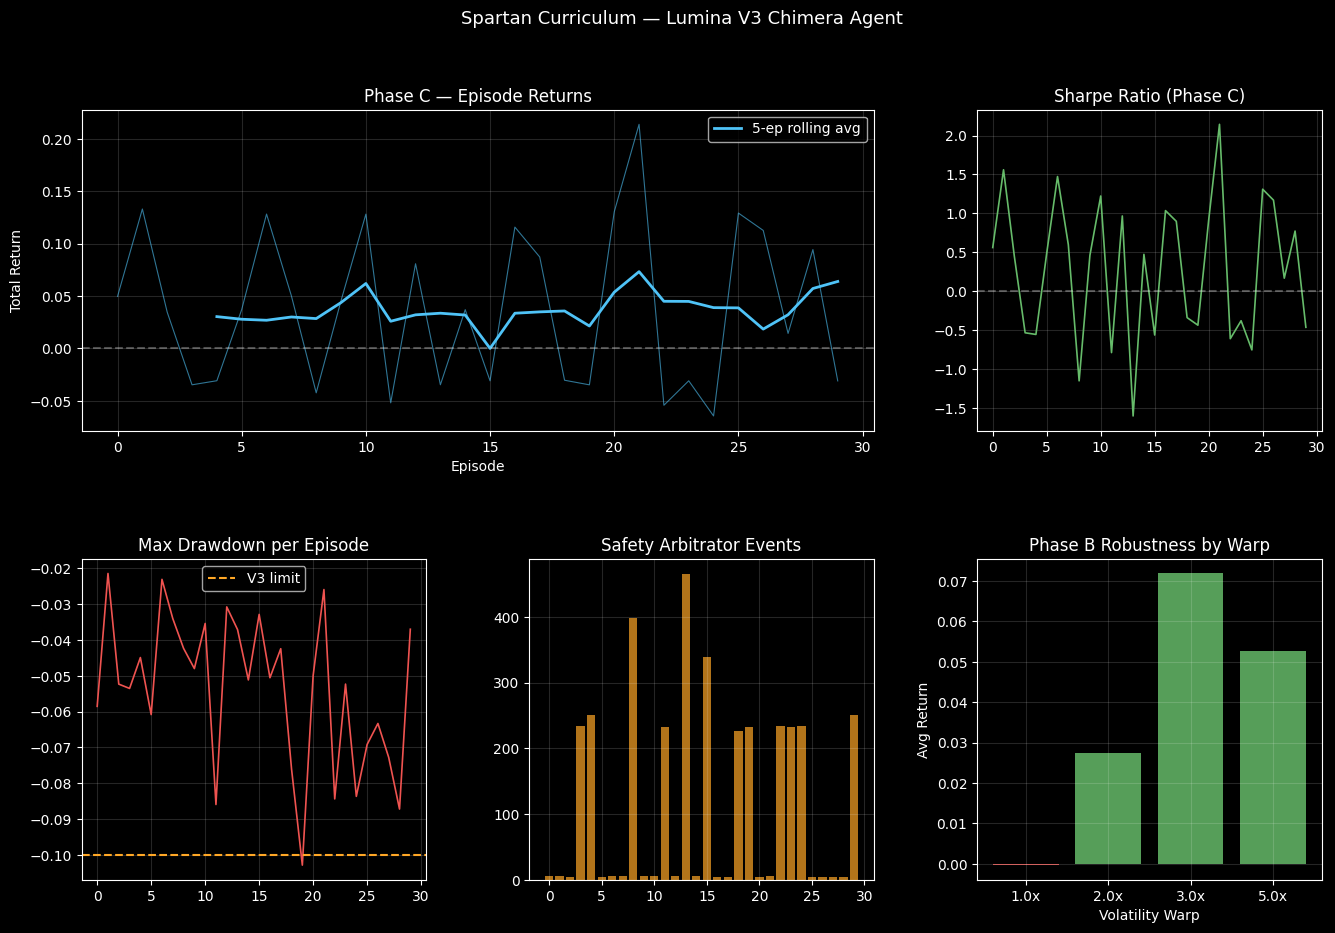

Saved → 09_curriculum.png


In [10]:
fig = plt.figure(figsize=(16, 10))
gs = plt.GridSpec(2, 3, hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :2])
raw_r = phase_c["returns"]
ax1.plot(raw_r, color=COLORS["primary"], linewidth=0.8, alpha=0.6)
ax1.plot(
    pd.Series(raw_r).rolling(5).mean(),
    color=COLORS["primary"],
    linewidth=2.0,
    label="5-ep rolling avg",
)
ax1.axhline(0, color="white", linestyle="--", alpha=0.3)
ax1.set_title("Phase C — Episode Returns")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Total Return")
ax1.legend()
ax1.grid(alpha=0.15)

ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(phase_c["sharpe"], color=COLORS["success"], linewidth=1.2)
ax2.axhline(0, color="white", linestyle="--", alpha=0.3)
ax2.set_title("Sharpe Ratio (Phase C)")
ax2.grid(alpha=0.15)

ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(phase_c["max_dd"], color=COLORS["danger"], linewidth=1.2)
ax3.axhline(
    -MAX_DRAWDOWN_LIMIT,
    color=COLORS["warning"],
    linestyle="--",
    linewidth=1.5,
    label="V3 limit",
)
ax3.set_title("Max Drawdown per Episode")
ax3.legend()
ax3.grid(alpha=0.15)

ax4 = fig.add_subplot(gs[1, 1])
ax4.bar(
    range(len(phase_c["safety"])),
    phase_c["safety"],
    color=COLORS["warning"],
    alpha=0.7,
)
ax4.set_title("Safety Arbitrator Events")
ax4.grid(alpha=0.15)

ax5 = fig.add_subplot(gs[1, 2])
if phase_b_results:
    warps = [str(r["warp"]) + "x" for r in phase_b_results]
    avgs = [r["avg_return"] for r in phase_b_results]
    cols = [COLORS["success"] if a >= 0 else COLORS["danger"] for a in avgs]
    ax5.bar(warps, avgs, color=cols, alpha=0.85)
    ax5.set_title("Phase B Robustness by Warp")
    ax5.set_xlabel("Volatility Warp")
    ax5.set_ylabel("Avg Return")
    ax5.grid(alpha=0.15)

plt.suptitle("Spartan Curriculum — Lumina V3 Chimera Agent", fontsize=13)
plt.savefig("09/09_curriculum.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 09_curriculum.png")

## 10. Final Milestone — 2020 COVID Crash Test (§9 Q4)


  Q4 FINAL MILESTONE — 2020 COVID Crash Test
  Total Return     : +8.27%
  Sharpe Ratio     : 0.9084
  Max Drawdown     : -6.30%
  Kill Switch      : ✅ NOT triggered
  Safety Events    : 8
  Unc. Gate Vetos  : 0 / 250 steps (0.0%)

  Q4 MILESTONE : ✅  PASS


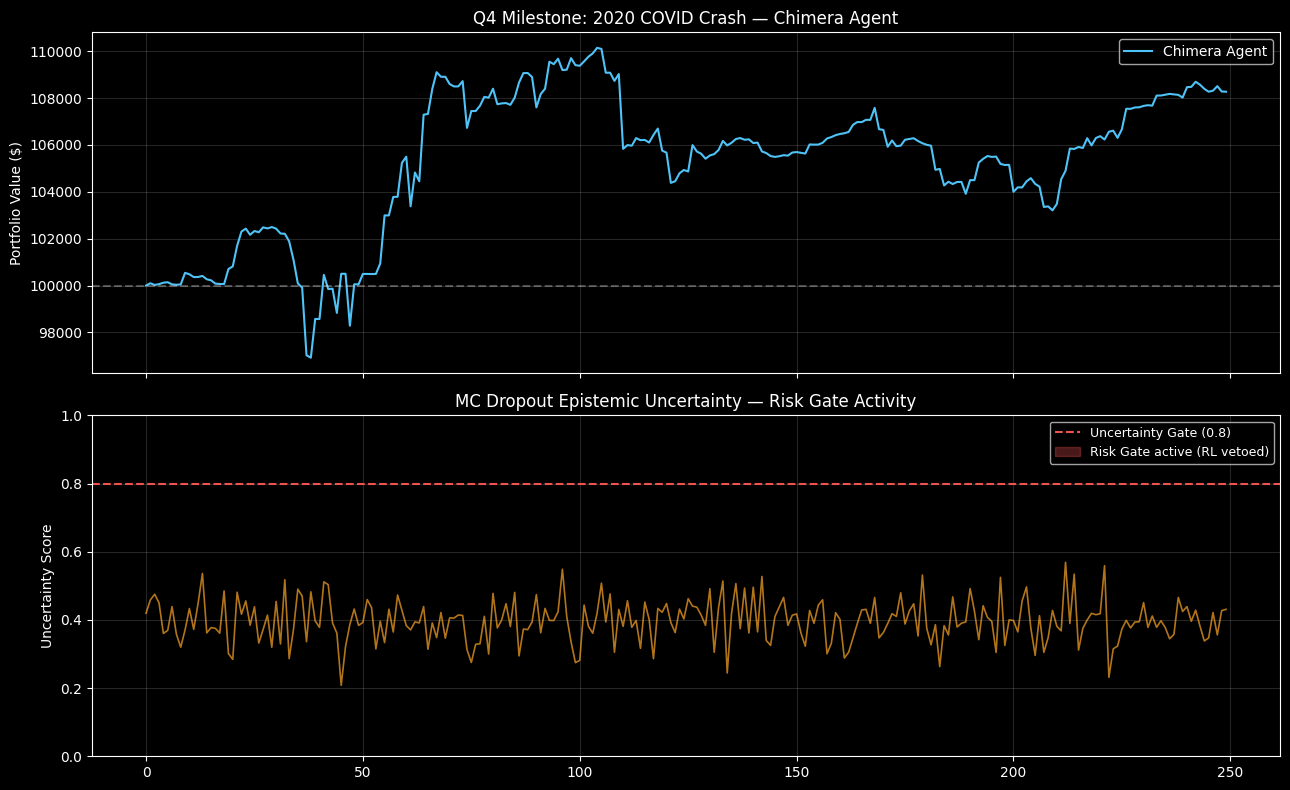

In [11]:
# "The Agent navigates a simulated 2020-style crash without hitting the
#  hard kill-switch, preserving capital through autonomous decision-making."
print("\n" + "=" * 52)
print("  Q4 FINAL MILESTONE — 2020 COVID Crash Test")
print("=" * 52)

crash_raw = yf.download(
    "SPY",
    start="2020-01-01",
    end="2020-12-31",
    interval="1d",
    progress=False,
    auto_adjust=True,
)
crash_px = crash_raw["Close"].squeeze().dropna().values.astype(np.float32)
n_crash = len(crash_px)
crash_ss = np.random.randn(n_crash, SUPER_STATE_DIM).astype(np.float32)

crash_env = LuminaTradingEnv(crash_px, crash_ss, initial_capital=100_000.0)
obs = crash_env.reset()
done = False
unc_log = []
model_C.eval()

while not done:
    obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    unc = estimate_uncertainty(model_C, obs_t)
    unc_log.append(unc)

    if unc > UNCERTAINTY_CRITICAL:
        action = np.array([0.0, 0.3, 0.0, 0.5])
    else:
        with torch.no_grad():
            out = model_C(obs_t)
            action = model_C.scale_actions(out["actions"])[0].cpu().numpy()

    obs, _, done, _ = crash_env.step(action)

crash_stats = crash_env.stats()
eq = crash_stats.get("equity", np.array([100_000.0]))
kill_sw = crash_stats.get("max_dd", 0) < -MAX_DRAWDOWN_LIMIT
unc_vetos = sum(1 for u in unc_log if u > UNCERTAINTY_CRITICAL)

print(f"  Total Return     : {crash_stats.get('total_return', 0):+.2%}")
print(f"  Sharpe Ratio     : {crash_stats.get('sharpe', 0):.4f}")
print(f"  Max Drawdown     : {crash_stats.get('max_dd', 0):+.2%}")
print(
    f"  Kill Switch      : {'⚠️  TRIGGERED' if kill_sw else '✅ NOT triggered'}"
)
print(f"  Safety Events    : {crash_stats.get('n_safe', 0)}")
print(
    f"  Unc. Gate Vetos  : {unc_vetos} / {len(unc_log)} steps "
    f"({unc_vetos / max(len(unc_log), 1):.1%})"
)

milestone = not kill_sw and crash_stats.get("total_return", -1) > -0.20
milestone_str = "✅  PASS" if milestone else "❌  FAIL — continue training"
print(f"\n  Q4 MILESTONE : {milestone_str}")

# Visualise crash episode
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(eq, color=COLORS["primary"], linewidth=1.5, label="Chimera Agent")
axes[0].axhline(100_000, color="white", linestyle="--", alpha=0.3)
axes[0].set_title("Q4 Milestone: 2020 COVID Crash — Chimera Agent")
axes[0].set_ylabel("Portfolio Value ($)")
axes[0].legend()
axes[0].grid(alpha=0.15)

axes[1].plot(unc_log, color=COLORS["warning"], linewidth=1.2, alpha=0.7)
axes[1].axhline(
    UNCERTAINTY_CRITICAL,
    color=COLORS["danger"],
    linestyle="--",
    linewidth=1.5,
    label=f"Uncertainty Gate ({UNCERTAINTY_CRITICAL})",
)
axes[1].fill_between(
    range(len(unc_log)),
    unc_log,
    UNCERTAINTY_CRITICAL,
    where=[u > UNCERTAINTY_CRITICAL for u in unc_log],
    color=COLORS["danger"],
    alpha=0.3,
    label="Risk Gate active (RL vetoed)",
)
axes[1].set_ylim(0, 1)
axes[1].set_title("MC Dropout Epistemic Uncertainty — Risk Gate Activity")
axes[1].set_ylabel("Uncertainty Score")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.15)

plt.tight_layout()
plt.savefig("09/09_crash_milestone.png", dpi=150, bbox_inches="tight")
plt.show()

# Save trained agent checkpoint
torch.save(model_C.state_dict(), "09/09_chimera_agent.pt")